In [1]:
import gdsfactory as gf
import gdsfactory as gf
from gdsfactory.generic_tech import get_generic_pdk
import numpy as np

PDK = get_generic_pdk()
PDK.activate()

/tmp/ipykernel_48000/450421049.py:3: DeprecationWarning: The 'gdsfactory.generic_tech' module is deprecated and will be removed in a future version. Please update your imports to use 'gdsfactory.gpdk' instead:
  from gdsfactory.gpdk import LAYER, LAYER_STACK, get_generic_pdk
Or for submodules:
  from gdsfactory.gpdk.layer_map import LAYER
  from gdsfactory.gpdk.layer_stack import LAYER_STACK
  from gdsfactory.generic_tech import get_generic_pdk


/home/flore/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/cachetools/_cached.py:185: UserWarning: bend_euler angle should be 90 or 180. Got -90. Use bend_euler_all_angle instead.
  v = func(*args, **kwargs)


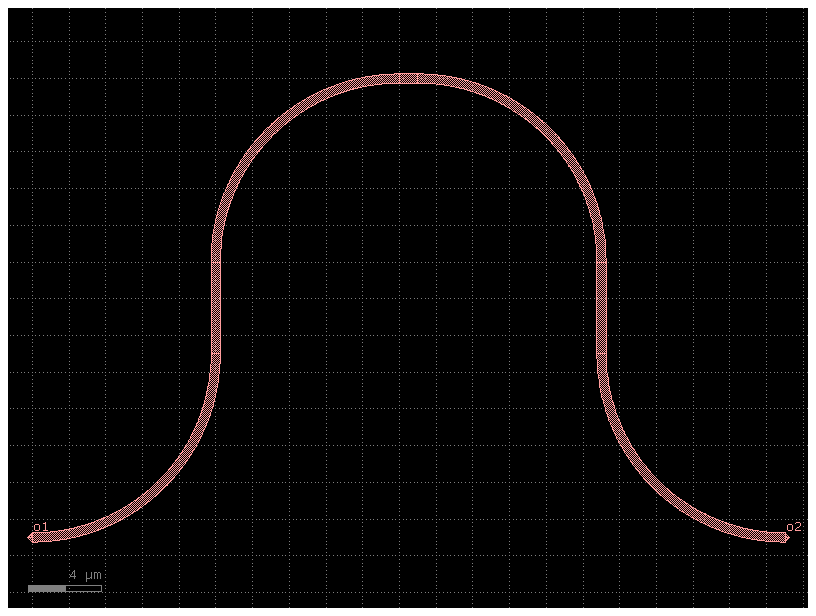

In [2]:
gf.clear_cache()
@gf.cell
def half_MZI(L_arm=10):
    m= gf.Component()
    #parte de arriba
    bend_in_up1 = m << gf.components.bend_circular(angle=-90, width=0.5, cross_section='strip', allow_min_radius_violation=False)
    bend_in_up2 = m << gf.components.bend_circular(angle=-90, width=0.5, cross_section='strip', allow_min_radius_violation=False)
    wgu = m << gf.components.straight(length=1, width=0.5, cross_section='strip')

    #conexiones del MZI con los directional couplers
    wg_izq = m << gf.components.straight(length=L_arm, width=0.5, cross_section='strip')
    wg_der = m << gf.components.straight(length=L_arm, width=0.5, cross_section='strip')
    bend_izq = m << gf.components.bend_circular(angle=90, width=0.5, cross_section='strip', allow_min_radius_violation=False)
    bend_der = m << gf.components.bend_circular(angle=90, width=0.5, cross_section='strip', allow_min_radius_violation=False)

    bend_in_up1.connect("o2", wgu.ports["o1"], allow_width_mismatch=True, allow_layer_mismatch = True)
    bend_in_up2.connect("o1", wgu.ports["o2"], allow_width_mismatch=True, allow_layer_mismatch = True)
    wg_izq.connect("o2", bend_in_up1.ports["o1"], allow_width_mismatch=True, allow_layer_mismatch = True)
    wg_der.connect("o1", bend_in_up2.ports["o2"], allow_width_mismatch=True, allow_layer_mismatch = True)
    bend_izq.connect("o2", wg_izq.ports["o1"], allow_width_mismatch=True, allow_layer_mismatch = True)
    bend_der.connect("o1", wg_der.ports["o2"], allow_width_mismatch=True, allow_layer_mismatch = True)

    m.add_port(name="o1", port=bend_izq.ports["o1"], port_type="optical")
    m.add_port(name="o2", port=bend_der.ports["o2"], port_type="optical")
    return m
    

m = gf.Component()
h = m << half_MZI(L_arm=5)
m.add_ports(h.ports)
m.draw_ports()
m.plot()

/home/flore/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/cachetools/_cached.py:185: UserWarning: bend_euler angle should be 90 or 180. Got -90. Use bend_euler_all_angle instead.
  v = func(*args, **kwargs)


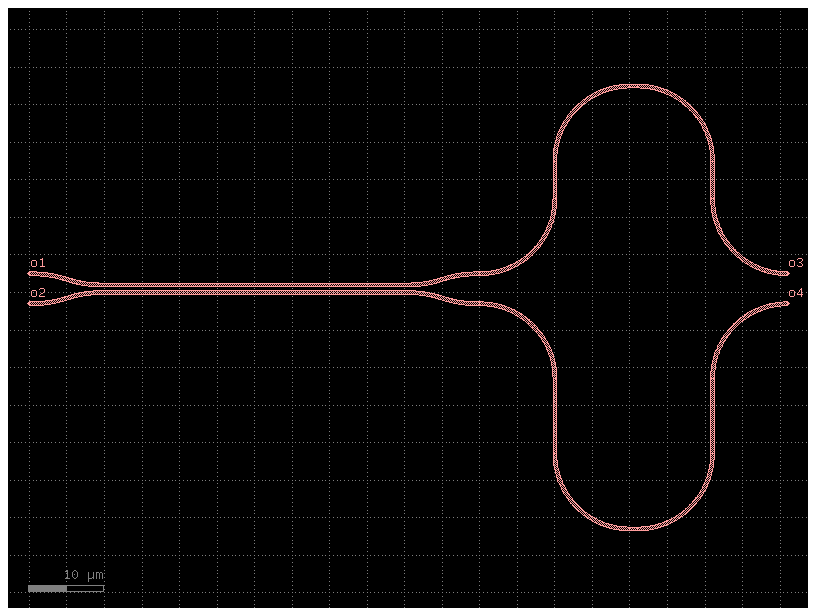

In [3]:
gf.clear_cache()
@gf.cell
def MZI(L_arm_up=10, L_arm_down=10, L_dc=10):
    m = gf.Component()
    h1 = m << half_MZI(L_arm=L_arm_up)
    h2 = m << half_MZI(L_arm=L_arm_down)
    dc = m << gf.components.coupler(length=L_dc, gap=0.5, dy=4, dx=10, cross_section='strip', bend="bend_s")

    h2.mirror_y()
    h1.connect("o1", dc.ports["o3"], allow_width_mismatch=True, allow_layer_mismatch = True)
    h2.connect("o1", dc.ports["o4"], allow_width_mismatch=True, allow_layer_mismatch = True)

    m.add_port(name="o1", port=dc.ports["o2"], port_type="optical")
    m.add_port(name="o2", port=dc.ports["o1"], port_type="optical")
    m.add_port(name="o3", port=h1.ports["o2"], port_type="optical")
    m.add_port(name="o4", port=h2.ports["o2"], port_type="optical")    
    return m

m = gf.Component()
h = m << MZI(L_arm_up=5, L_arm_down=10, L_dc=40)
m.add_ports(h.ports)
m.draw_ports()
m.plot()

Para poder hacer el layout es necesario saber cuanto deben medir los directional coupler y cual debe ser la diferencia entre los MZI. Las medidas de los directional couplers ya los obtuvimos en la parte 2. Para sacar ΔL únicamente necesitamos usar ΔL=(λ0^2)/(ng*FSR), como sabemos que λ0=1550nm, ng=4.2754 y el FSR = 40nm (sacado del paper), llegamos a que necesitamos una diferencia entre los MZI de 14.05 um. Con esto ya podemos sacar todo.

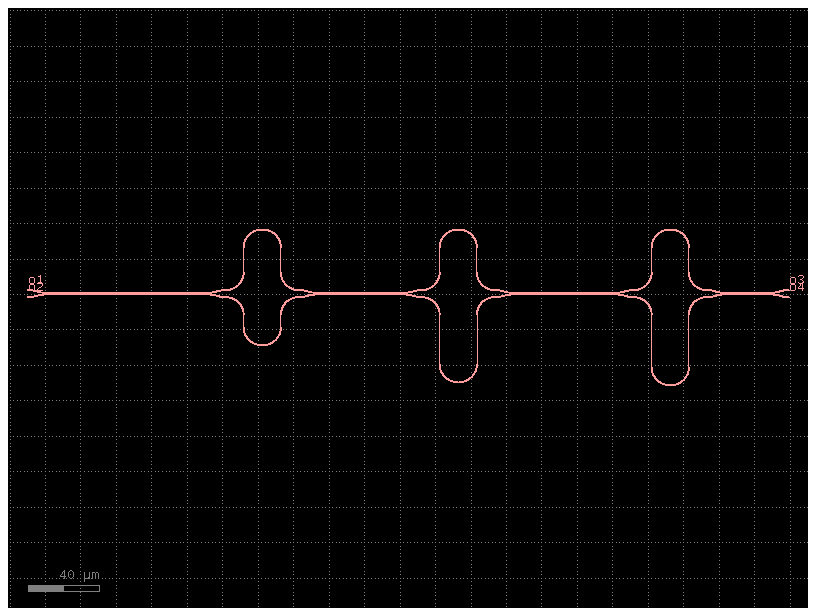

In [4]:
gf.clear_cache()
@gf.cell
def s1():
    L1=28.1
    L2=14.05
    m = gf.Component()
    MZI_1 = m << MZI(L_arm_up=L1/2, L_arm_down=L2/2, L_dc=91.763)
    MZI_2 = m << MZI(L_arm_up=2*L2/2, L_arm_down=2*L1/2, L_dc=49.654)
    MZI_3 = m << MZI(L_arm_up=2*L2/2, L_arm_down=2*L1/2+np.pi/2, L_dc=58.439)
    dc_final = m << gf.components.coupler(length=26.348, gap=0.45, dy=4, dx=10, cross_section='strip', bend="bend_s")

    #Hay que tener en cuenta que estoy moviendo el MZI_2 al MZI_1 y el MZI_3 al MZI_2, por lo que las conexiones se hacen al revés. Es decir, el puerto o3 del MZI_1 se conecta al puerto o1 del MZI_2, y el puerto o4 del MZI_1 se conecta al puerto o2 del MZI_2. Lo mismo ocurre con el MZI_3, que se conecta al MZI_2.
    #Que elemento pones primero en el .connect es importante porque mueves el primer elemento al segundo (si no lo tienes en cuenta puede darte problemas)
    MZI_2.connect("o1", MZI_1.ports["o3"], allow_width_mismatch=True, allow_layer_mismatch = True)
    MZI_2.connect("o2", MZI_1.ports["o4"], allow_width_mismatch=True, allow_layer_mismatch = True)

    MZI_3.connect("o1", MZI_2.ports["o3"], allow_width_mismatch=True, allow_layer_mismatch = True)
    MZI_3.connect("o2", MZI_2.ports["o4"], allow_width_mismatch=True, allow_layer_mismatch = True)

    dc_final.connect("o1", MZI_3.ports["o4"], allow_width_mismatch=True, allow_layer_mismatch = True)
    dc_final.connect("o2", MZI_3.ports["o3"], allow_width_mismatch=True, allow_layer_mismatch = True)


    m.add_port(name="o1", port=MZI_1.ports["o1"], port_type="optical")
    m.add_port(name="o2", port=MZI_1.ports["o2"], port_type="optical")
    m.add_port(name="o3", port=dc_final.ports["o3"], port_type="optical")
    m.add_port(name="o4", port=dc_final.ports["o4"], port_type="optical")
    return m

s = gf.Component()
h = s << s1()
s.add_ports(h.ports)
s.draw_ports()
s.plot()
    

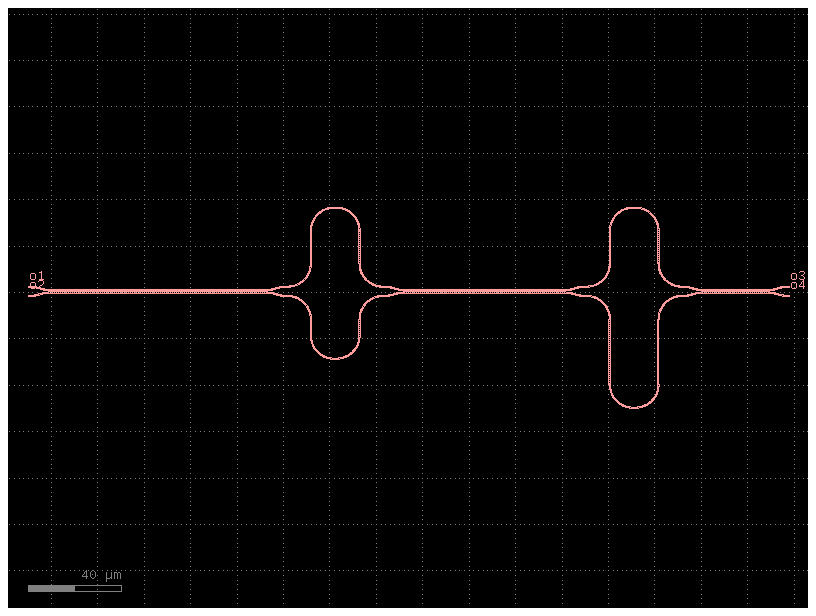

In [5]:
gf.clear_cache()
@gf.cell
def s2():
    L1=28.1
    L2=14.05
    m = gf.Component()
    MZI_1 = m << MZI(L_arm_up=L1/2, L_arm_down=L2/2, L_dc=91.763)
    MZI_2 = m << MZI(L_arm_up=2*L2/2, L_arm_down=2*L1/2, L_dc=67.723)
    dc_final = m << gf.components.coupler(length=26.348, gap=0.45, dy=4, dx=10, cross_section='strip', bend="bend_s")

    MZI_2.connect("o1", MZI_1.ports["o3"], allow_width_mismatch=True, allow_layer_mismatch = True)
    MZI_2.connect("o2", MZI_1.ports["o4"], allow_width_mismatch=True, allow_layer_mismatch = True)
    
    dc_final.connect("o1", MZI_2.ports["o4"], allow_width_mismatch=True, allow_layer_mismatch = True)
    dc_final.connect("o2", MZI_2.ports["o3"], allow_width_mismatch=True, allow_layer_mismatch = True)

    m.add_port(name="o1", port=MZI_1.ports["o1"], port_type="optical")
    m.add_port(name="o2", port=MZI_1.ports["o2"], port_type="optical")
    m.add_port(name="o3", port=dc_final.ports["o3"], port_type="optical")
    m.add_port(name="o4", port=dc_final.ports["o4"], port_type="optical")
    return m

s = gf.Component()
h = s << s2()
s.add_ports(h.ports)
s.draw_ports()
s.plot()
    

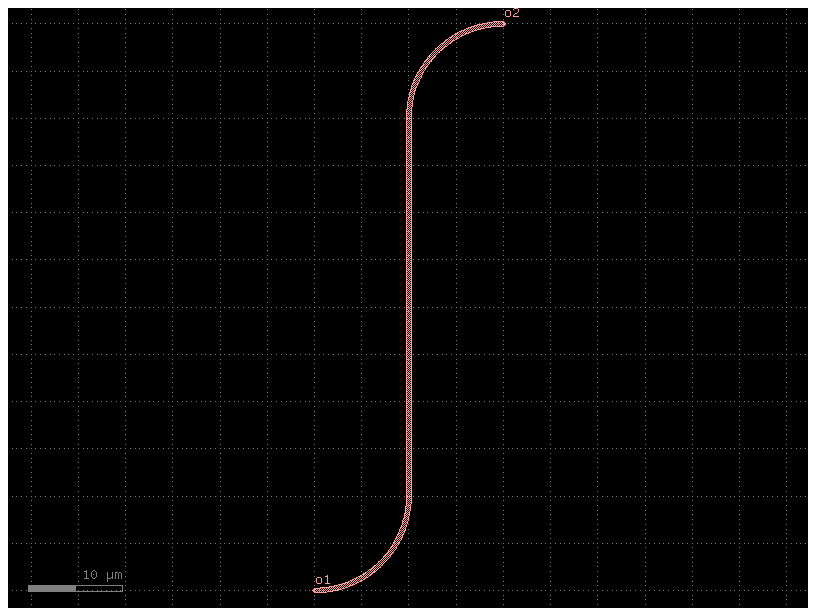

In [6]:
gf.clear_cache()
@gf.cell
def conector():
    m = gf.Component()
    bend_1 = m << gf.components.bend_circular(angle=90, width=0.5, cross_section='strip', allow_min_radius_violation=False)
    bend_2 = m << gf.components.bend_circular(angle=-90, width=0.5, cross_section='strip', allow_min_radius_violation=False)
    wg= m << gf.components.straight(length=40, width=0.5, cross_section='strip')

    wg.connect("o1", bend_1.ports["o2"], allow_width_mismatch=True, allow_layer_mismatch = True)
    bend_2.connect("o1", wg.ports["o2"], allow_width_mismatch=True, allow_layer_mismatch = True)

    m.add_port(name="o1", port=bend_1.ports["o1"], port_type="optical")
    m.add_port(name="o2", port=bend_2.ports["o2"], port_type="optical")
    return m

s = gf.Component()
h = s << conector()
s.add_ports(h.ports)
s.draw_ports()
s.plot()
    

/home/flore/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/cachetools/_cached.py:185: UserWarning: bend_euler angle should be 90 or 180. Got -90. Use bend_euler_all_angle instead.
  v = func(*args, **kwargs)


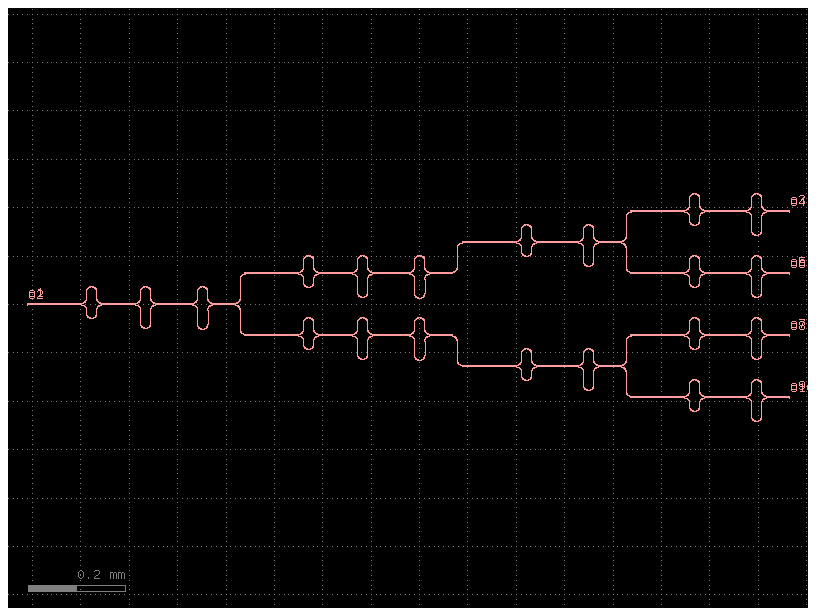

In [13]:
gf.clear_cache()
@gf.cell
def demutiplexor():
    m = gf.Component()
    s1_1 = m << s1()
    conector_1_up = m << conector()
    conector_1_down = m << conector()
    s1_2_up = m << s1()
    s1_2_down = m << s1()

    conector_2_up = m << conector()
    conector_2_down = m << conector()
    s2_3_up = m << s2()
    s2_3_down = m << s2()

    conector_3_up1 = m << conector()
    conector_3_up2 = m << conector()
    conector_3_down1 = m << conector()
    conector_3_down2 = m << conector()
    s2_4_up1 = m << s2()
    s2_4_up2 = m << s2()
    s2_4_down1 = m << s2()
    s2_4_down2 = m << s2()


    conector_1_down.mirror_y()
    conector_2_down.mirror_y()
    conector_3_up2.mirror_y()
    conector_3_down2.mirror_y()

    conector_1_up.connect("o1", s1_1.ports["o3"], allow_width_mismatch=True, allow_layer_mismatch = True)
    conector_1_down.connect("o1", s1_1.ports["o4"], allow_width_mismatch=True, allow_layer_mismatch = True)
    s1_2_up.connect("o2", conector_1_up.ports["o2"], allow_width_mismatch=True, allow_layer_mismatch = True)
    s1_2_down.connect("o1", conector_1_down.ports["o2"], allow_width_mismatch=True, allow_layer_mismatch = True)

    conector_2_up.connect("o1", s1_2_up.ports["o3"], allow_width_mismatch=True, allow_layer_mismatch = True)
    conector_2_down.connect("o1", s1_2_down.ports["o4"], allow_width_mismatch=True, allow_layer_mismatch = True)
    s2_3_up.connect("o2", conector_2_up.ports["o2"], allow_width_mismatch=True, allow_layer_mismatch = True)
    s2_3_down.connect("o1", conector_2_down.ports["o2"], allow_width_mismatch=True, allow_layer_mismatch = True)

    conector_3_up1.connect("o1", s2_3_up.ports["o3"], allow_width_mismatch=True, allow_layer_mismatch = True)
    conector_3_up2.connect("o1", s2_3_up.ports["o4"], allow_width_mismatch=True, allow_layer_mismatch = True)
    conector_3_down1.connect("o1", s2_3_down.ports["o3"], allow_width_mismatch=True, allow_layer_mismatch = True)
    conector_3_down2.connect("o1", s2_3_down.ports["o4"], allow_width_mismatch=True, allow_layer_mismatch = True)
    s2_4_up1.connect("o2", conector_3_up1.ports["o2"], allow_width_mismatch=True, allow_layer_mismatch = True)
    s2_4_up2.connect("o1", conector_3_up2.ports["o2"], allow_width_mismatch=True, allow_layer_mismatch = True)
    s2_4_down1.connect("o2", conector_3_down1.ports["o2"], allow_width_mismatch=True, allow_layer_mismatch = True)
    s2_4_down2.connect("o1", conector_3_down2.ports["o2"], allow_width_mismatch=True, allow_layer_mismatch = True)

    m.add_port(name="o1", port=s1_1.ports["o1"], port_type="optical")
    m.add_port(name="o2", port=s1_1.ports["o2"], port_type="optical")
    m.add_port(name="o3", port=s2_4_up1.ports["o3"], port_type="optical")
    m.add_port(name="o4", port=s2_4_up1.ports["o4"], port_type="optical")
    m.add_port(name="o5", port=s2_4_up2.ports["o3"], port_type="optical")
    m.add_port(name="o6", port=s2_4_up2.ports["o4"], port_type="optical") 
    m.add_port(name="o7", port=s2_4_down1.ports["o3"], port_type="optical")
    m.add_port(name="o8", port=s2_4_down1.ports["o4"], port_type="optical")
    m.add_port(name="o9", port=s2_4_down2.ports["o3"], port_type="optical")
    m.add_port(name="o10", port=s2_4_down2.ports["o4"], port_type="optical")

    return m

s = gf.Component()
demux = s << demutiplexor()
s.add_ports(demux.ports)
s.draw_ports()
s.plot()

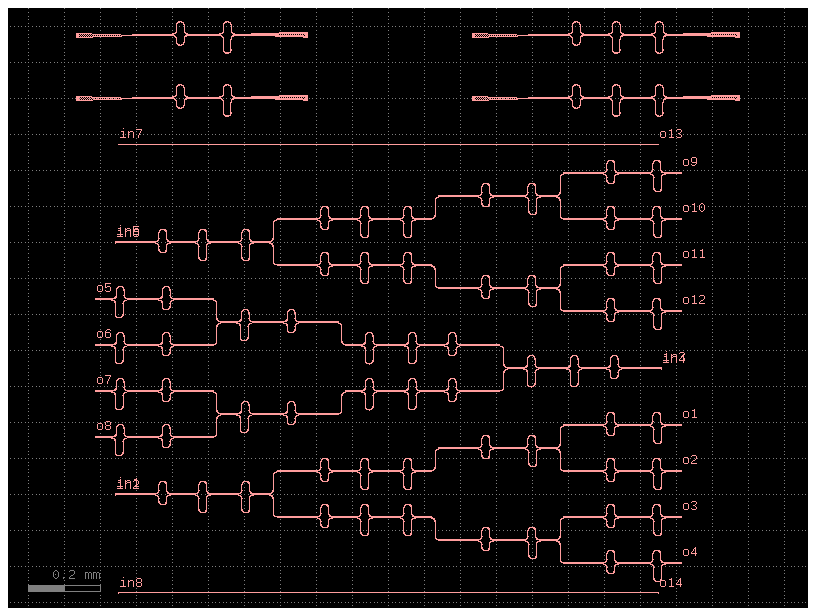

In [28]:
gf.clear_cache()
def sistema():
    c = gf.Component()
    # Definimos todos los componentes del sistema final
        # s1,s2
    lin_up = 20
    lin_down=20
    s1_1 = c << s1()
    s1_2 = c << s1()
    s2_1 = c << s2()
    s2_2 = c << s2()

        # Grating couplers
    g1 = c << gf.components.grating_coupler_rectangular_arbitrary(gaps=(0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2), widths=(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5), width_grating=11, length_taper=150, polarization='te', wavelength=1.55, slab_xmin=-1, slab_offset=1, fiber_angle=15, cross_section='strip')
    g2 = c << gf.components.grating_coupler_rectangular_arbitrary(gaps=(0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2), widths=(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5), width_grating=11, length_taper=150, polarization='te', wavelength=1.55, slab_xmin=-1, slab_offset=1, fiber_angle=15, cross_section='strip')
    g3 = c << gf.components.grating_coupler_rectangular_arbitrary(gaps=(0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2), widths=(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5), width_grating=11, length_taper=150, polarization='te', wavelength=1.55, slab_xmin=-1, slab_offset=1, fiber_angle=15, cross_section='strip')
    g4 = c << gf.components.grating_coupler_rectangular_arbitrary(gaps=(0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2), widths=(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5), width_grating=11, length_taper=150, polarization='te', wavelength=1.55, slab_xmin=-1, slab_offset=1, fiber_angle=15, cross_section='strip')
    g5 = c << gf.components.grating_coupler_rectangular_arbitrary(gaps=(0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2), widths=(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5), width_grating=11, length_taper=150, polarization='te', wavelength=1.55, slab_xmin=-1, slab_offset=1, fiber_angle=15, cross_section='strip')
    g6 = c << gf.components.grating_coupler_rectangular_arbitrary(gaps=(0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2), widths=(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5), width_grating=11, length_taper=150, polarization='te', wavelength=1.55, slab_xmin=-1, slab_offset=1, fiber_angle=15, cross_section='strip')
    g7 = c << gf.components.grating_coupler_rectangular_arbitrary(gaps=(0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2), widths=(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5), width_grating=11, length_taper=150, polarization='te', wavelength=1.55, slab_xmin=-1, slab_offset=1, fiber_angle=15, cross_section='strip')
    g8 = c << gf.components.grating_coupler_rectangular_arbitrary(gaps=(0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2), widths=(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5), width_grating=11, length_taper=150, polarization='te', wavelength=1.55, slab_xmin=-1, slab_offset=1, fiber_angle=15, cross_section='strip')
    gin1= c << gf.components.grating_coupler_rectangular_arbitrary(gaps=(0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2), widths=(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5), width_grating=11, length_taper=150, polarization='te', wavelength=1.55, slab_xmin=-1, slab_offset=1, fiber_angle=15, cross_section='strip')
    gin2 = c << gf.components.grating_coupler_rectangular_arbitrary(gaps=(0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2), widths=(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5), width_grating=11, length_taper=150, polarization='te', wavelength=1.55, slab_xmin=-1, slab_offset=1, fiber_angle=15, cross_section='strip')
    gin3= c << gf.components.grating_coupler_rectangular_arbitrary(gaps=(0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2), widths=(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5), width_grating=11, length_taper=150, polarization='te', wavelength=1.55, slab_xmin=-1, slab_offset=1, fiber_angle=15, cross_section='strip')
    gin4 = c << gf.components.grating_coupler_rectangular_arbitrary(gaps=(0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2), widths=(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5), width_grating=11, length_taper=150, polarization='te', wavelength=1.55, slab_xmin=-1, slab_offset=1, fiber_angle=15, cross_section='strip')

        # Filtros 
    system1 = c<< demutiplexor()
    system2 =c<< demutiplexor()
    system3 =c<< demutiplexor()
        # Waveguides
    wg_test1 = c <<gf.components.straight(length=1500, npoints=2, cross_section='strip')
    wg_test2 = c <<gf.components.straight(length=1500, npoints=2, cross_section='strip')
    # Desplazamos
    dy = 350
    dx = 400
    system2.dmovey(dy)
    system2.dmirror_x()
    system3.dmovey(2*dy)
    system1.dmovex(-1500/2)
    system3.dmovex(-1500/2)
    system2.dmovex(1500/2)
    wg_test1.dmovex(-1500/2).dmovey(2.75*dy+10)
    wg_test2.dmovex(-1500/2).dmovey(-dy/1.35-15)
    s1_1.dmovey(3.15*dy).dmovex(dx)
    s1_2.dmovey(3.65*dy).dmovex(dx)
    s2_1.dmovey(3.15*dy).dmovex(-3.5/2*dx)
    s2_2.dmovey(3.65*dy).dmovex(-3.5/2*dx)
    gin1.drotate(180)
    gin2.drotate(180)
    gin3.drotate(180)
    gin4.drotate(180)

    # Conectamos
    g1.connect(port="o1", other = s1_1.ports["o3"], allow_width_mismatch=True, allow_layer_mismatch = True)
    g2.connect(port="o1", other = s1_1.ports["o4"], allow_width_mismatch=True, allow_layer_mismatch = True)
    g3.connect(port="o1", other = s1_2.ports["o3"], allow_width_mismatch=True, allow_layer_mismatch = True)
    g4.connect(port="o1", other = s1_2.ports["o4"], allow_width_mismatch=True, allow_layer_mismatch = True)
    g5.connect(port="o1", other = s2_1.ports["o3"], allow_width_mismatch=True, allow_layer_mismatch = True)
    g6.connect(port="o1", other = s2_1.ports["o4"], allow_width_mismatch=True, allow_layer_mismatch = True)
    g7.connect(port="o1", other = s2_2.ports["o3"], allow_width_mismatch=True, allow_layer_mismatch = True)
    g8.connect(port="o1", other = s2_2.ports["o4"], allow_width_mismatch=True, allow_layer_mismatch = True)
    gin1.connect(port="o1", other = s1_1.ports["o2"], allow_width_mismatch=True, allow_layer_mismatch = True)
    gin2.connect(port="o1", other = s1_2.ports["o2"], allow_width_mismatch=True, allow_layer_mismatch = True)
    gin3.connect(port="o1", other = s2_1.ports["o2"], allow_width_mismatch=True, allow_layer_mismatch = True)
    gin4.connect(port="o1", other = s2_2.ports["o2"], allow_width_mismatch=True, allow_layer_mismatch = True)

    # Entradas
    c.add_port("in1", port=system1.ports["o1"],port_type="optical")
    c.add_port("in2", port=system1.ports["o2"],port_type="optical")
    c.add_port("in3", port=system2.ports["o1"],port_type="optical")
    c.add_port("in4", port=system2.ports["o2"],port_type="optical")
    c.add_port("in5", port=system3.ports["o1"],port_type="optical")
    c.add_port("in6", port=system3.ports["o2"],port_type="optical")
    c.add_port("in7", port=wg_test1.ports["o1"],port_type="optical")
    c.add_port("in8", port=wg_test2.ports["o1"],port_type="optical")
    # Salidas
    c.add_port("o1", port=system1.ports["o3"],port_type="optical")
    c.add_port("o2", port=system1.ports["o5"],port_type="optical")
    c.add_port("o3", port=system1.ports["o7"],port_type="optical")
    c.add_port("o4", port=system1.ports["o9"],port_type="optical")
    c.add_port("o5", port=system2.ports["o3"],port_type="optical")
    c.add_port("o6", port=system2.ports["o5"],port_type="optical")
    c.add_port("o7", port=system2.ports["o7"],port_type="optical")
    c.add_port("o8", port=system2.ports["o9"],port_type="optical")
    c.add_port("o9", port=system3.ports["o3"],port_type="optical")
    c.add_port("o10", port=system3.ports["o5"],port_type="optical")
    c.add_port("o11", port=system3.ports["o7"],port_type="optical")
    c.add_port("o12", port=system3.ports["o9"],port_type="optical")
    c.add_port("o13", port=wg_test1.ports["o2"],port_type="optical")
    c.add_port("o14", port=wg_test2.ports["o2"],port_type="optical")

    return c

c = gf.Component()

h = c << sistema()
c.add_ports(h.ports)
c.draw_ports()
c.plot()



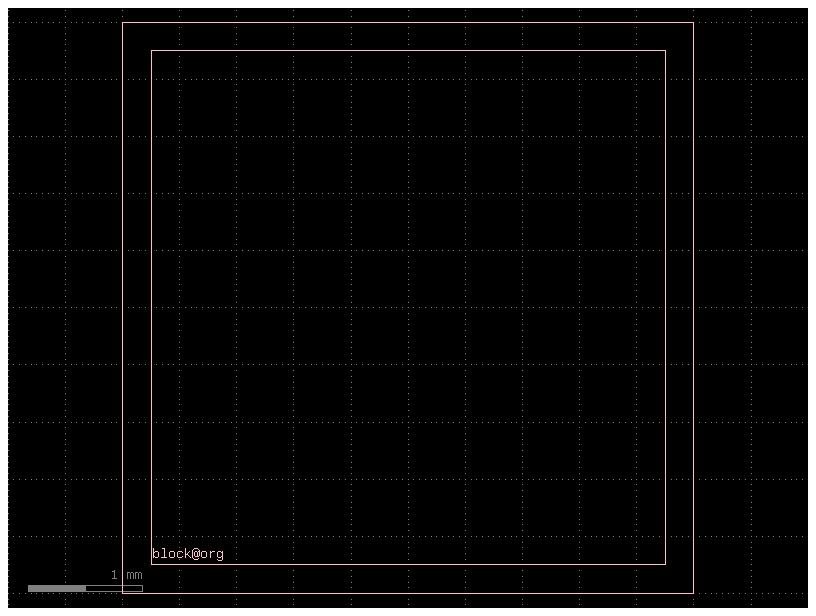

In [8]:
#esto es la celda donde se va a meter todo el layout del chip, con el die y el demultiplexor dentro. 
gf.clear_cache()

@gf.cell
def die(dieL = 5000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    # Adding ports to a component 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

a = gf.Component()
box = a << die()
a.add_ports(box.ports)
a.draw_ports()
a.plot()

2026-05-14 15:06:55.667 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


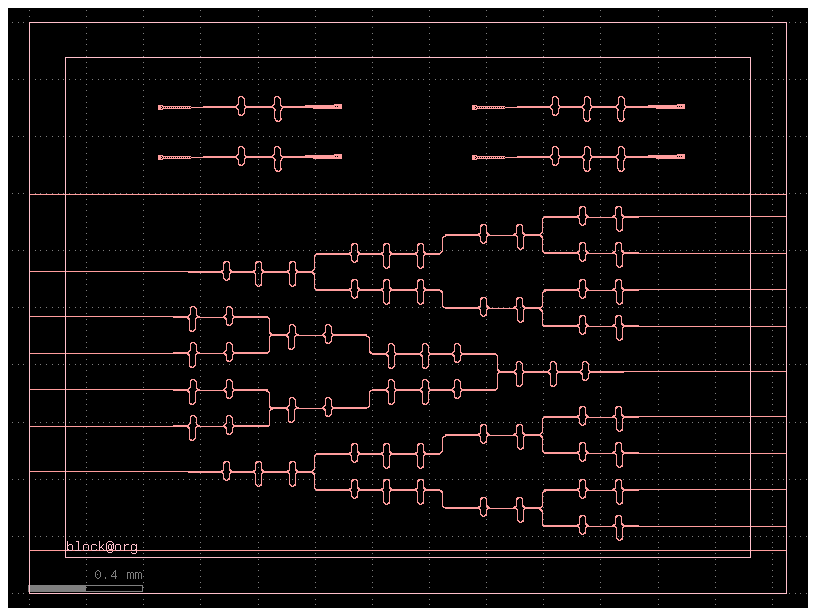

In [29]:
dieL = 2000
dieW = 2650
border = 125
layer_wg = "WG"
layer_box = "FLOORPLAN"

# Die specifications (Chip)
box = gf.Component()

die_ref = box.add_ref(die(dieW = dieW, dieL = dieL,border = border, layer_box="FLOORPLAN"))

# Adding the system to the chip
sys = sistema()
system_ref = box.add_ref(sys)
system_ref.dmovex(die_ref["block@org"].dx + 0.45*dieW).dmovey(die_ref['block@org'].dy + 300)

# Entradas y salidas al chip
xs = 'strip'
strin_in1 = (box.add_ref(gf.components.straight(length=300, cross_section='strip')).dmovex(0).dmovey(system_ref['in1'].dy))
strin_in2 = (box.add_ref(gf.components.straight(length=300, cross_section='strip')).dmovex(dieW-300).dmovey(system_ref['in3'].dy))
strin_in3 = (box.add_ref(gf.components.straight(length=300, cross_section='strip')).dmovex(0).dmovey(system_ref['in5'].dy))
    # system1
strin_out1 = (box.add_ref(gf.components.straight(length=300, cross_section='strip')).dmovex(dieW-300).dmovey(system_ref['o1'].dy))
strin_out2 = (box.add_ref(gf.components.straight(length=300, cross_section='strip')).dmovex(dieW-300).dmovey(system_ref['o2'].dy))
strin_out3 = (box.add_ref(gf.components.straight(length=300, cross_section='strip')).dmovex(dieW-300).dmovey(system_ref['o3'].dy))
strin_out4 = (box.add_ref(gf.components.straight(length=300, cross_section='strip')).dmovex(dieW-300).dmovey(system_ref['o4'].dy))
    # system2
strin_out5 = (box.add_ref(gf.components.straight(length=300, cross_section='strip')).dmovex(0).dmovey(system_ref['o5'].dy))
strin_out6 = (box.add_ref(gf.components.straight(length=300, cross_section='strip')).dmovex(0).dmovey(system_ref['o6'].dy))
strin_out7 = (box.add_ref(gf.components.straight(length=300, cross_section='strip')).dmovex(0).dmovey(system_ref['o7'].dy))
strin_out8 = (box.add_ref(gf.components.straight(length=300, cross_section='strip')).dmovex(0).dmovey(system_ref['o8'].dy))
    # system3
strin_out9 = (box.add_ref(gf.components.straight(length=300, cross_section='strip')).dmovex(dieW-300).dmovey(system_ref['o9'].dy))
strin_out10 = (box.add_ref(gf.components.straight(length=300, cross_section='strip')).dmovex(dieW-300).dmovey(system_ref['o10'].dy))
strin_out11 = (box.add_ref(gf.components.straight(length=300, cross_section='strip')).dmovex(dieW-300).dmovey(system_ref['o11'].dy))
strin_out12 = (box.add_ref(gf.components.straight(length=300, cross_section='strip')).dmovex(dieW-300).dmovey(system_ref['o12'].dy))
    # wavwguides
strin_wg1 = (box.add_ref(gf.components.straight(length=300, cross_section='strip')).dmovex(0).dmovey(system_ref['in7'].dy))
strin_wg2 = (box.add_ref(gf.components.straight(length=300, cross_section='strip')).dmovex(dieW-300).dmovey(system_ref['o13'].dy))
strin_wg3 = (box.add_ref(gf.components.straight(length=300, cross_section='strip')).dmovex(0).dmovey(system_ref['in8'].dy))
strin_wg4 = (box.add_ref(gf.components.straight(length=300, cross_section='strip')).dmovex(dieW-300).dmovey(system_ref['o14'].dy))


### Then route from the i/o waveguides to the MMI
    # Entradas sistemas
gf.routing.route_single_sbend(box,port1=strin_in1['o2'], port2=system_ref['in1'], cross_section=xs)
gf.routing.route_single_sbend(box, port1=system_ref['in3'],port2=strin_in2['o1'], cross_section=xs)
gf.routing.route_single_sbend(box,port1=strin_in3['o2'], port2=system_ref['in5'], cross_section=xs)
    # Salidas sistema1
gf.routing.route_single_sbend(box,port1=system_ref['o1'],port2=strin_out1['o1'], cross_section=xs)
gf.routing.route_single_sbend(box,port1=system_ref['o2'],port2=strin_out2['o1'], cross_section=xs)
gf.routing.route_single_sbend(box,port1=system_ref['o3'],port2=strin_out3['o1'], cross_section=xs)
gf.routing.route_single_sbend(box,port1=system_ref['o4'],port2=strin_out4['o1'], cross_section=xs)
    # Salidas sistema2
gf.routing.route_single_sbend(box,port1=strin_out5['o2'],port2=system_ref['o5'],cross_section=xs)
gf.routing.route_single_sbend(box,port1=strin_out6['o2'],port2=system_ref['o6'],cross_section=xs)
gf.routing.route_single_sbend(box,port1=strin_out7['o2'],port2=system_ref['o7'],cross_section=xs)
gf.routing.route_single_sbend(box,port1=strin_out8['o2'],port2=system_ref['o8'],cross_section=xs)
    # Salidas sistema3
gf.routing.route_single_sbend(box,port1=system_ref['o9'],port2=strin_out9['o1'], cross_section=xs)
gf.routing.route_single_sbend(box,port1=system_ref['o10'],port2=strin_out10['o1'], cross_section=xs)
gf.routing.route_single_sbend(box,port1=system_ref['o11'],port2=strin_out11['o1'], cross_section=xs)
gf.routing.route_single_sbend(box,port1=system_ref['o12'],port2=strin_out12['o1'], cross_section=xs)
    # waveguides
gf.routing.route_single_sbend(box,port1=strin_wg1['o2'],port2=system_ref['in7'], cross_section=xs)
gf.routing.route_single_sbend(box,port1=system_ref['o13'],port2=strin_wg2['o1'], cross_section=xs)
gf.routing.route_single_sbend(box,port1=strin_wg3['o2'],port2=system_ref['in8'], cross_section=xs)
gf.routing.route_single_sbend(box,port1=system_ref['o14'],port2=strin_wg4['o1'], cross_section=xs)

box.draw_ports()
box.show()
box.plot()